In [1]:
#Importing basic library

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt

In [2]:
#Load the data

(x_train, y_train) , (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train:", x_train.shape, "| Test:", x_test.shape)
print("Pixel range:", x_train.min(), "to", x_train.max())
print("Labels shape:", y_train.shape)

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train: (50000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: 0 to 255
Labels shape: (50000, 1)


In [3]:
#Normalizing the training data

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print(f"After normalizing, training pixel reange is {x_train.min()} to {x_train.max()}")

After normalizing, training pixel reange is 0.0 to 1.0


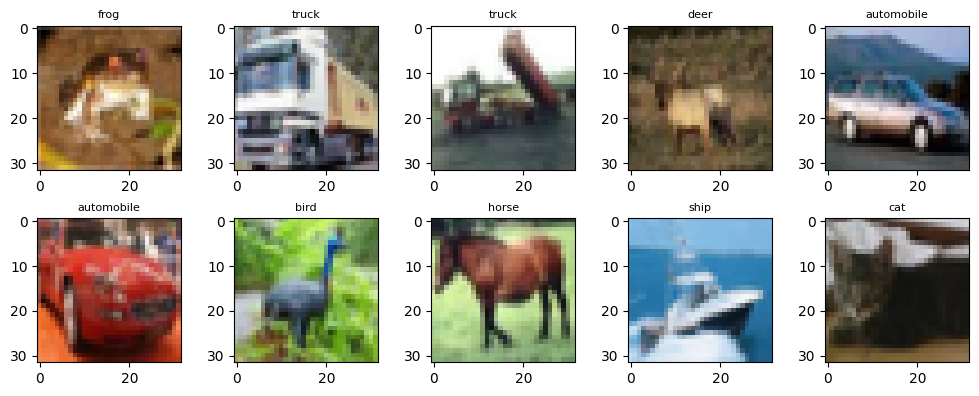

In [4]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]],fontsize = 8)
    plt.axis = "off"
plt.tight_layout()
plt.show()

In [5]:
#Model building

model = models.Sequential([
    layers.Conv2D( 32 , (3,3) , activation="relu" , padding="same" , input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Conv2D( 64 , (3,3) , activation="relu" , padding="same" ),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Conv2D( 128 , (3,3) , activation="relu" , padding="same" ),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dropout(0.25),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.25),
    layers.Dense(10 , activation="softmax")
])
model.summary ()

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True
)

datagen.fit(x_train)

model.compile(
    optimizer = "Adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["Accuracy"]
)

history = model.fit(
    datagen.flow(x_train,y_train,batch_size=64),
    epochs = 40,
    validation_data = (x_test,y_test),
    callbacks = [
        tf.keras.callbacks.EarlyStopping( patience = 5 , restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau( patience = 3 , factore = 0.5 , verbose = 1)
    ]
)

print("model trained")

Epoch 1/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 114s 140ms/step - Accuracy: 0.4228 - loss: 1.6144 - val_Accuracy: 0.5283 - val_loss: 1.3171 - learning_rate: 0.0010
Epoch 2/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 115s 147ms/step - Accuracy: 0.5409 - loss: 1.2776 - val_Accuracy: 0.5935 - val_loss: 1.1294 - learning_rate: 0.0010
Epoch 3/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 110s 140ms/step - Accuracy: 0.5996 - loss: 1.1334 - val_Accuracy: 0.6444 - val_loss: 1.0079 - learning_rate: 0.0010
Epoch 4/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 124s 158ms/step - Accuracy: 0.6336 - loss: 1.0401 - val_Accuracy: 0.6893 - val_loss: 0.8859 - learning_rate: 0.0010
Epoch 5/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 110s 141ms/step - Accuracy: 0.6585 - loss: 0.9754 - val_Accuracy: 0.6875 - val_loss: 0.8914 - learning_rate: 0.0010
Epoch 6/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 135ms/step - Accuracy: 0.6787 - loss: 0.9238 - val_Accuracy: 0.7062 - val_loss: 0.8617 - learning_rate: 0.0010
Epoch 7/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 104s 133ms/step - Accura

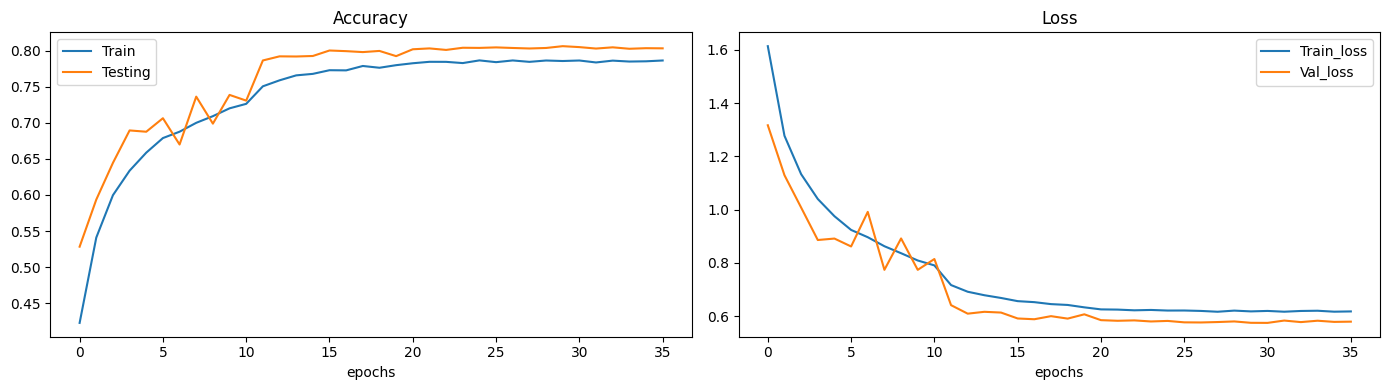

In [12]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
plt.plot(history.history["Accuracy"],label="Train")
plt.plot(history.history["val_Accuracy"],label="Testing")
plt.title("Accuracy")
plt.xlabel("epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"],label="Train_loss")
plt.plot(history.history["val_loss"],label="Val_loss")
plt.title("Loss")
plt.xlabel("epochs")
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


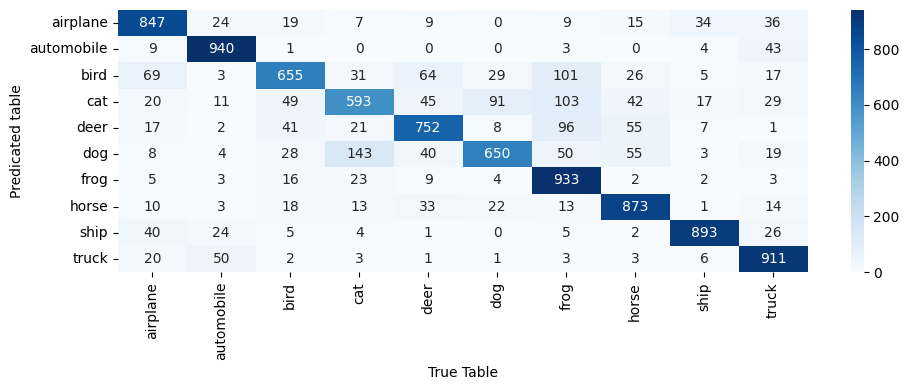

In [18]:
from sklearn.metrics import *
import seaborn as sns

y_pred = model.predict(x_test)
y_pred_class = np.argmax(y_pred,axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true,y_pred_class)

plt.figure(figsize=(10,4))
sns.heatmap(cm, annot = True , fmt = "d",
            xticklabels = class_names,
            yticklabels = class_names,
            cmap = "Blues"
           )
plt.xlabel("True Table")
plt.ylabel("Predicated table")
plt.tight_layout()
plt.show()

In [19]:
model.save("cifar10_cnn.h5")
print("model_saved")

model_saved
